# <center><strong>Social Media User Analysis</strong></center>
----------------------------------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

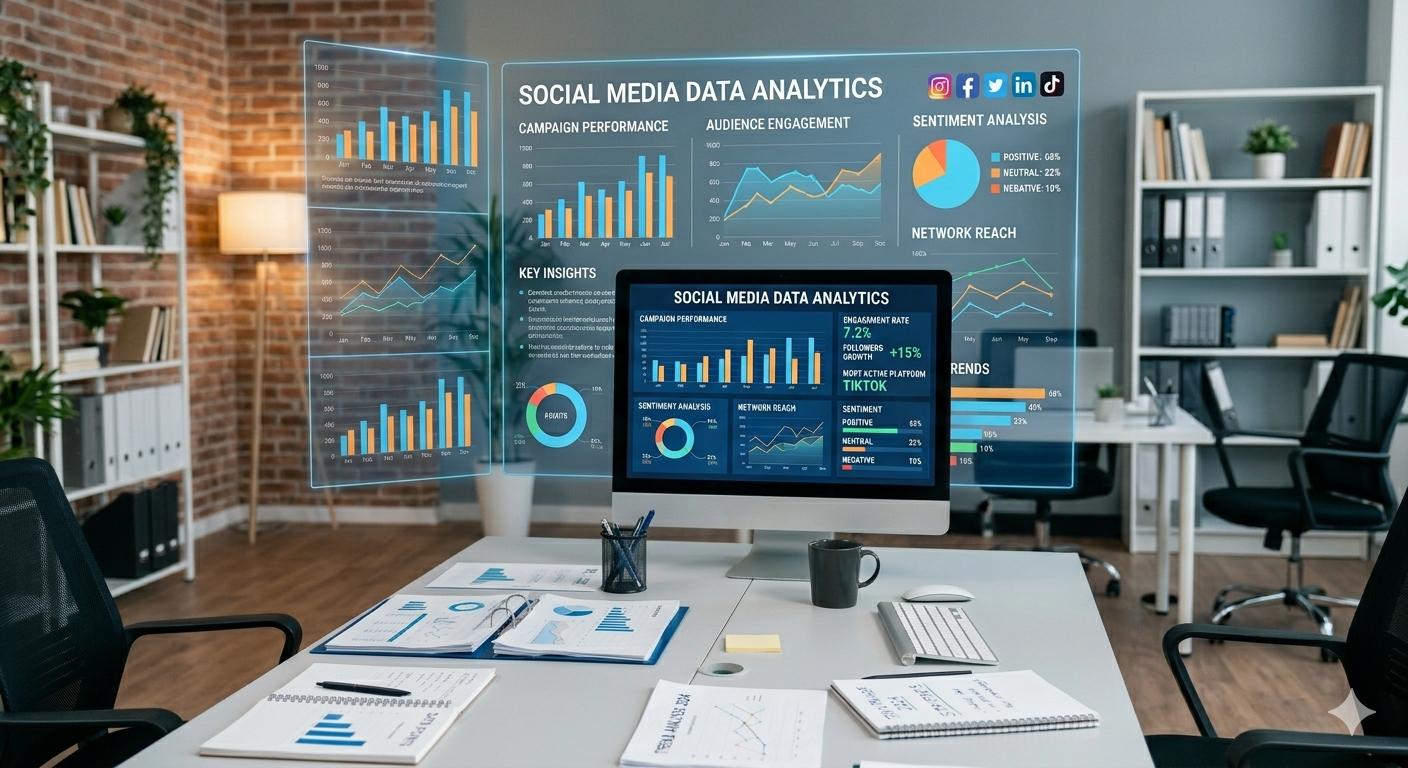

In [1]:
from IPython.display import Image
Image(filename='logo a.png')

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import *

from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.xlabel(col)
    plt.show()

def countplot(data,col):
    plt.fig,ax= plt.subplots()
    plt.fig.set_size_inches(18,5)    
    sns.countplot(x=data[col], data=df)
    plt.xlabel(col)
    plt.xticks(rotation = 45)
    plt.show()

def countplot2(data,x,hue,palette):
    plt.figure(figsize=(18,5))
    sns.countplot(data=data, x = x, hue=hue, palette=palette)
    plt.title(f'{x} by {hue}')
    plt.xlabel(x)
    plt.ylabel('count')
    plt.show()

def histplot(data, x, hue, palette):
    plt.figure(figsize=(14,5))
    sns.histplot(data=data, x=x, hue=hue, kde=True, bins=20, palette=palette)
    plt.title(f'{x} Distribution')
    plt.xlabel(x)
    plt.ylabel('Frequency')
    plt.show()

def barplot(data,x,y):
    plt.figure(figsize=(10, 5))
    sns.barplot(x=x, y=y, data=data, palette='viridis')
    plt.title(f'{x} by sum of {y}')
    plt.xlabel(x)
    plt.ylabel(f'Sum of {y}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.7)
    plt.tight_layout()
    plt.show()

---------------------------------------
---------------------------------------
---------------------------------------

### **Exploring Data**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [4]:
df = pd.read_csv('/kaggle/input/datasets/rockyt07/social-media-user-analysis/instagram_users_lifestyle.csv')
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [5]:
df.shape

(1547896, 58)

In [6]:
df.columns

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [8]:
df.isnull().sum()

user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_frequency_per_year   

In [9]:
df.duplicated().sum()

np.int64(0)

----------------------------------------------
----------------------------------------------
## **Data Cleaning**
----------------------------------------------

In [10]:
df=df.drop('user_id',axis=1)

In [11]:
df['education_level'].value_counts()

education_level
Bachelor’s      541083
High school     387323
Some college    309922
Master’s        185651
Other            77295
PhD              37003
Secondary         4364
Bachelor          2650
High School       2605
Name: count, dtype: int64

In [12]:
df['education_level'] = df['education_level'].replace('Bachelor’s','Bachelor')
df['education_level'] = df['education_level'].replace('High School','High school')

In [13]:
df['education_level'].value_counts()

education_level
Bachelor        543733
High school     389928
Some college    309922
Master’s        185651
Other            77295
PhD              37003
Secondary         4364
Name: count, dtype: int64

In [14]:
df['smoking'] = df['smoking'].replace('Former','No')

In [15]:
df['smoking'].value_counts()

smoking
No     1314963
Yes     232933
Name: count, dtype: int64

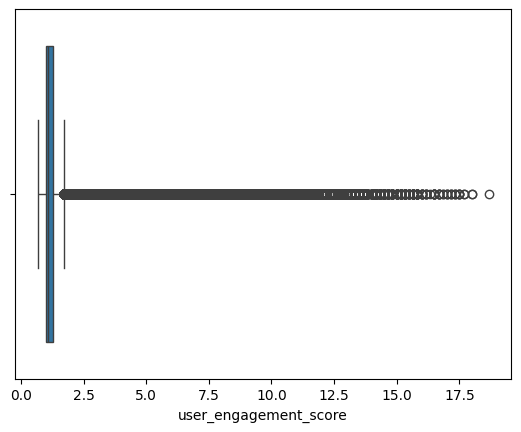

In [16]:
sns.boxplot(x='user_engagement_score',data=df)
plt.show()

In [17]:
Q1 = df['user_engagement_score'].quantile(0.25)
Q3 = df['user_engagement_score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['user_engagement_score'] < lower_bound) | (df['user_engagement_score'] > upper_bound)]

print(f"Upper bound: {upper_bound:.2f}")
print(f"Outliers: {len(outliers)}")

Upper bound: 1.73
Outliers: 202645


In [18]:
df=df.loc[df['user_engagement_score']<1.73]

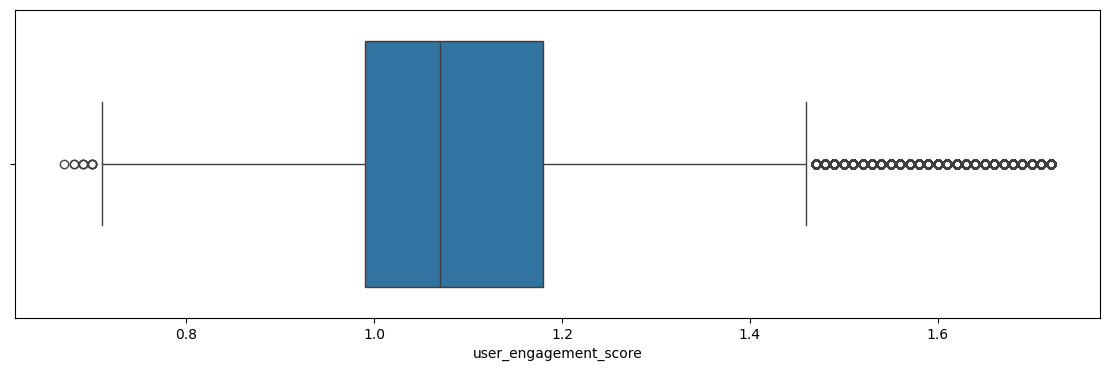

In [19]:
plt.figure(figsize=(14,4))
sns.boxplot(x='user_engagement_score', data=df)
plt.show()

-----------------------------
### **Checking Correlation between the features**
------------------------------

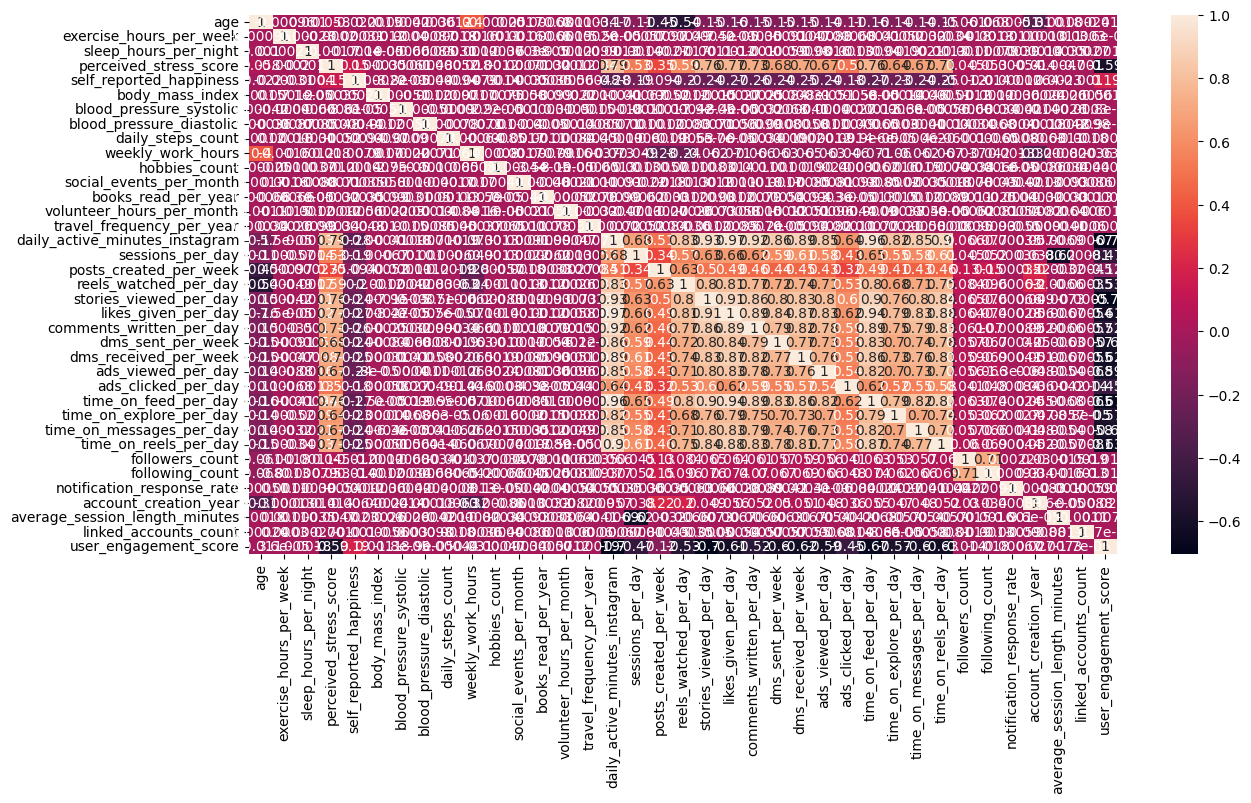

In [20]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

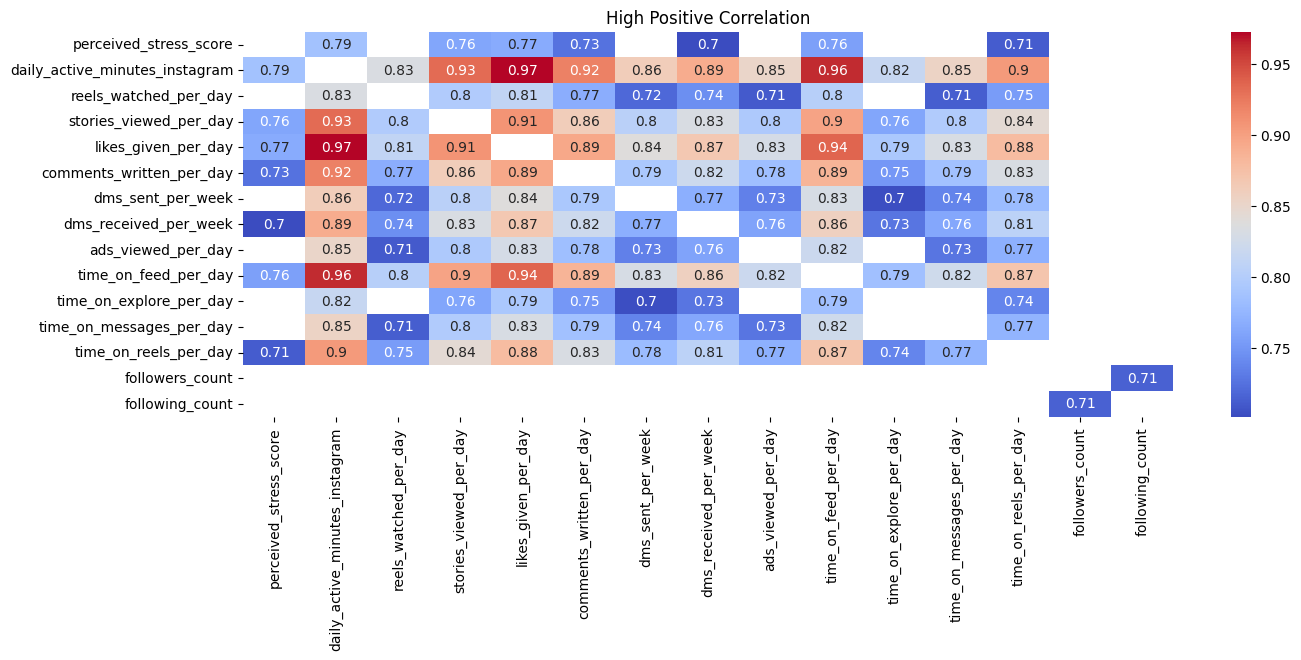

In [21]:
# function to extract high positive correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr >= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# get high positive correlated columns
high_corr = get_high_corr(df, 0.7)

# plot high positive correlated columns
plt.figure(figsize=(15, 5))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Positive Correlation')
plt.show()

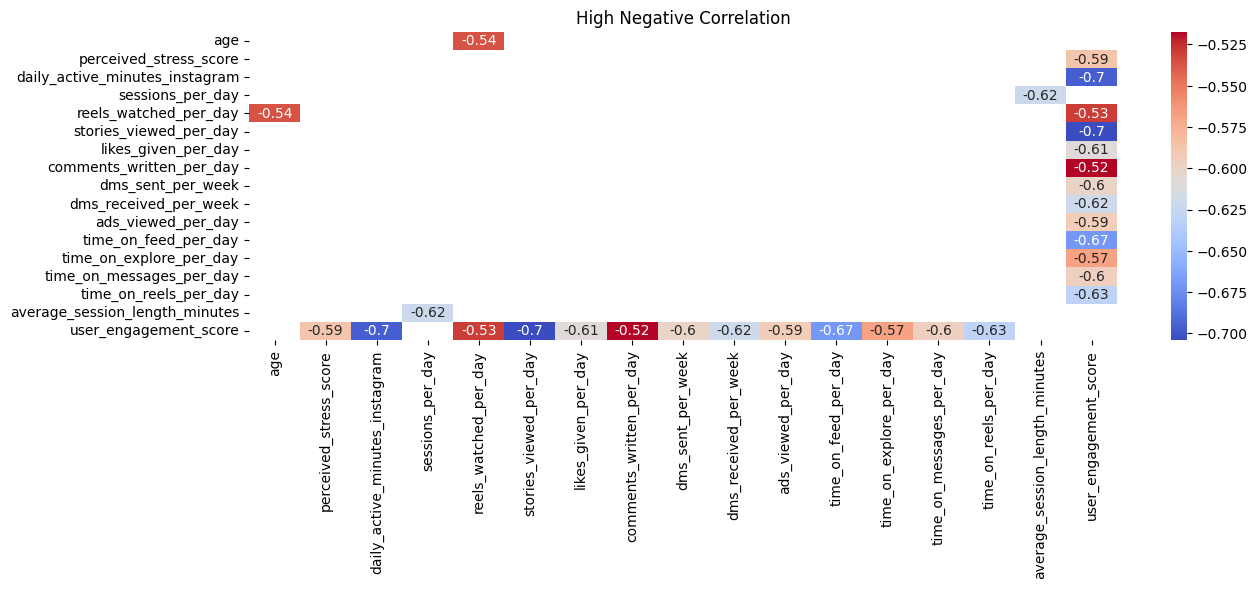

In [22]:
# function to extract high negative correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr <= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# get high negative correlated columns
high_corr = get_high_corr(df, -0.5)

# plot high negative correlated columns
plt.figure(figsize=(14, 4))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Negative Correlation')
plt.show()

------------------------------------------------------
----------------------------------------------------
## **Analysis**
---------------------------------
- #### **User engagement score**
-------------------------------

In [23]:
df['user_engagement_score'].describe()

count    1.345251e+06
mean     1.108485e+00
std      1.730507e-01
min      6.700000e-01
25%      9.900000e-01
50%      1.070000e+00
75%      1.180000e+00
max      1.720000e+00
Name: user_engagement_score, dtype: float64

In [24]:
mean = df['user_engagement_score'].mean()
std = df['user_engagement_score'].std()
dist = norm(mean, std)
prob_between_084_135 = dist.cdf(1.35) - dist.cdf(0.84)
print(f"P(0.84 < X < 1.35) = {prob_between_084_135:.4f} = {prob_between_084_135*100:.1f}%")

P(0.84 < X < 1.35) = 0.8582 = 85.8%


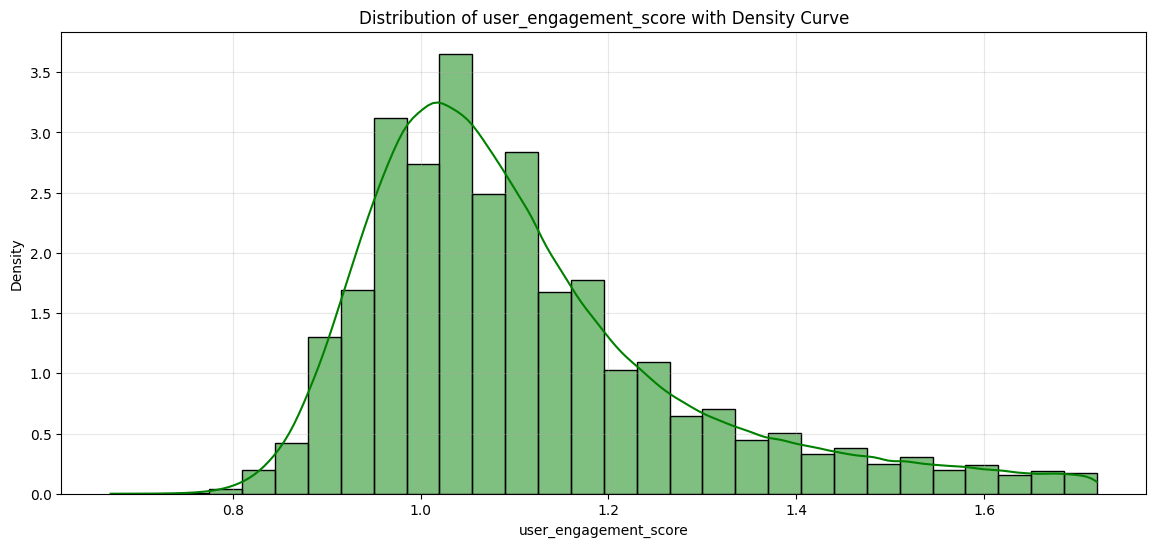

In [25]:
column_name='user_engagement_score'
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x=column_name, bins=30, kde=True, color='green', 
             stat='density', edgecolor='black')
plt.xlabel(column_name)
plt.ylabel('Density')
plt.title(f'Distribution of {column_name} with Density Curve')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
def scoreSeg(a):
    if a <= 0.84:
        return 'Passive Users'
    elif a <= 1.3:
        return 'Casual Users'
    else :
        return 'Power Users'

df['engagement_seg'] = df['user_engagement_score'].apply(lambda x: scoreSeg(x))

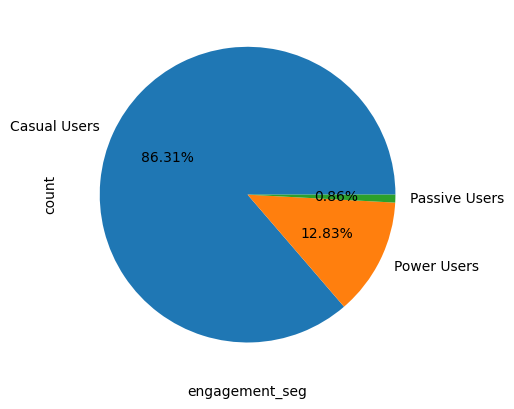

In [27]:
pie(df,'engagement_seg')

#### **Casual Users (86.31%)**
- ##### They constitute the vast majority.
- ##### They interact moderately or irregularly.
- ##### They are the most strategically important category because: their numbers are very large.

#### **Power Users (12.83%)**
- ##### A relatively good percentage.
- ##### These are: the most active and the most frequent users of the platform
- ##### Often the highest revenue contributors

#### **Passive Users (0.86%)**
- ##### A very low percentage.
- ##### Either: new users or virtually inactive

------------------------------
- #### **user engagement score vs daily active minutes on instagram**
-------------------------------

In [28]:
df['daily_active_minutes_instagram'].describe()

count    1.345251e+06
mean     2.133188e+02
std      9.533906e+01
min      1.600000e+01
25%      1.360000e+02
50%      2.080000e+02
75%      2.840000e+02
max      5.800000e+02
Name: daily_active_minutes_instagram, dtype: float64

In [29]:
r, p_value = pearsonr(df['daily_active_minutes_instagram'], df['user_engagement_score'])

print("Correlation:", r)
print("P-value:", p_value)

Correlation: -0.696339153248359
P-value: 0.0


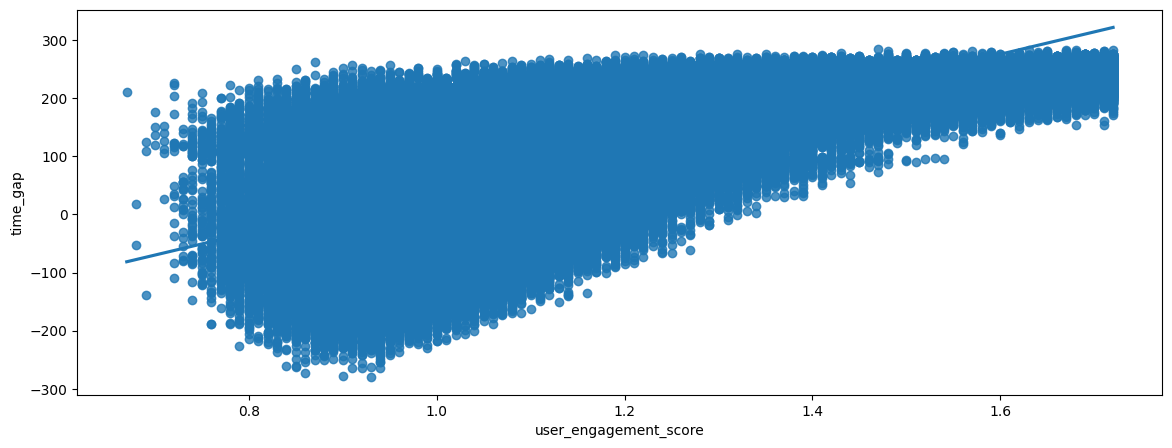

In [30]:
df['time_gap'] = 300 - df['daily_active_minutes_instagram']
plt.figure(figsize=(14,5))
sns.regplot(x=df['user_engagement_score'], y=df['time_gap'])
plt.show()

#### Objective of the Analysis: To study the relationship between time spent on the application and user engagement score to classify users and understand their digital behavior.

#### Key Insight (The "Paradox"): Initial analysis showed a negative correlation (r = −0.69), seemingly indicating that increased time decreases engagement. However, further investigation revealed that the score in the original data acts as a priority metric; high scores are assigned to highly efficient users (high engagement in a short time) who possess a significant time gap.

#### Statistical Findings:
- ##### A strong positive correlation was established between the time gap from the saturation threshold (300 minutes) and the engagement score.
- ##### The data exhibit a capping point of 300 minutes, suggesting the presence of a category of "power users" who exceed the limits of normal usage.

In [31]:
df = df[df['daily_active_minutes_instagram'] < 300]

---------------------------------
- #### **gender vs User engagement score**
-------------------------------

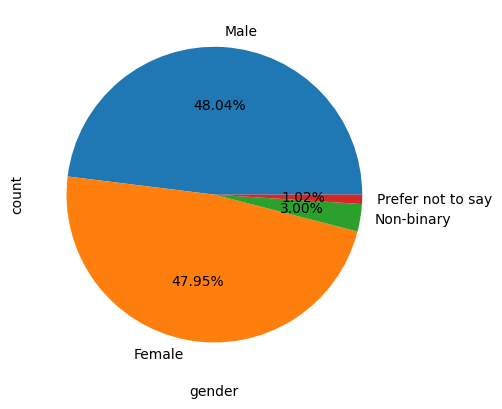

In [32]:
pie(df,'gender')

In [33]:
df.groupby('gender')['user_engagement_score'].mean()

gender
Female               1.142400
Male                 1.141978
Non-binary           1.141973
Prefer not to say    1.143765
Name: user_engagement_score, dtype: float64

In [34]:
male = df[df['gender'] == 'Male']['user_engagement_score']
female = df[df['gender'] == 'Female']['user_engagement_score']
non_binary = df[df['gender'] == 'Non-binary']['user_engagement_score']
prefer_not_to_say = df[df['gender'] == 'Prefer not to say']['user_engagement_score']

In [ ]:
def Shapiro(gender):
    stat, p = shapiro(gender)

    print(f'Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p:.4f}')
    
    if p > 0.05:
        print("The group follows a normal distribution (ANOVA)")
    else :
        print("The group does not follow the normal distribution (Kruskal-Wallis)")

In [36]:
Shapiro(male)

Shapiro-Wilk Statistic: 0.9228, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 514157.
  res = hypotest_fun_out(*samples, **kwds)


In [37]:
Shapiro(female)

Shapiro-Wilk Statistic: 0.9230, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 513150.
  res = hypotest_fun_out(*samples, **kwds)


In [38]:
Shapiro(non_binary)

Shapiro-Wilk Statistic: 0.9229, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 32112.
  res = hypotest_fun_out(*samples, **kwds)


In [39]:
Shapiro(prefer_not_to_say)

Shapiro-Wilk Statistic: 0.9234, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10865.
  res = hypotest_fun_out(*samples, **kwds)


- ##### Statistical Power of the Test: In this dataset, which includes thousands of records, the Shapiro-Wilk test has very high power to detect even the smallest deviations. Even if the data were 92% bell-shaped, the remaining 8% would be enough to cause the test to reject the normality hypothesis.

- ##### Sample Size Effect (N): In small samples (e.g., 30 people), a p-value of 0.92 would have yielded a p-value greater than 0.05, and the test would have accepted a normality hypothesis. However, in this dataset, the sample size is very large, making the test extremely picky.

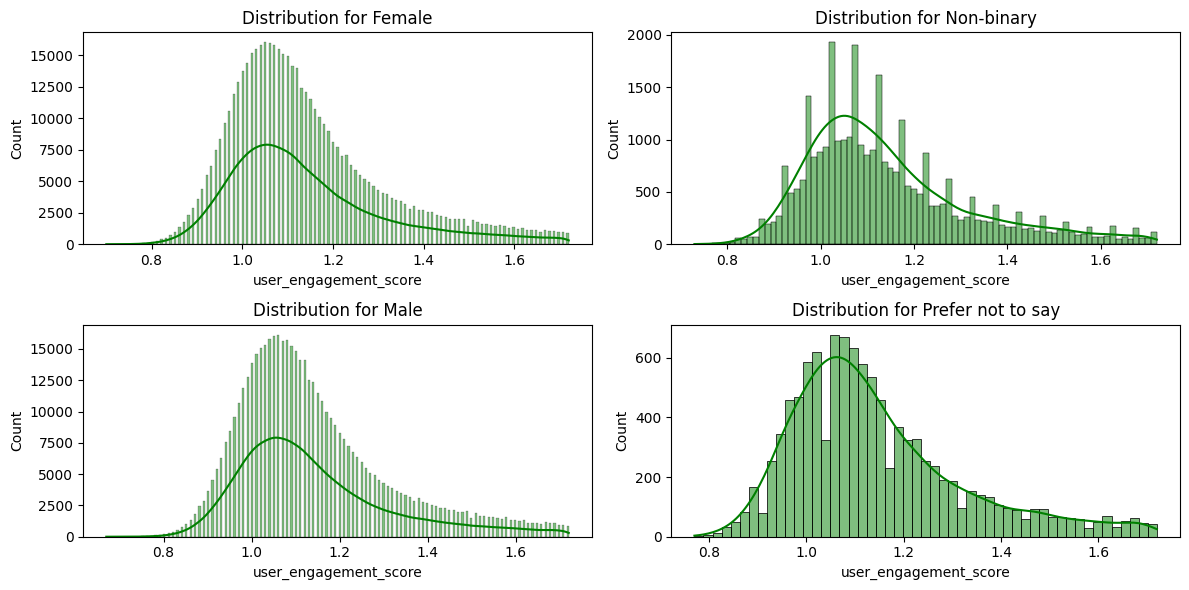

In [40]:
groups = df['gender'].unique()

plt.figure(figsize=(12, 6))

for i, group in enumerate(groups):
    data_group = df[df['gender'] == group]['user_engagement_score']
    
    plt.subplot(2, 2, i+1)
    sns.histplot(data_group, kde=True, color='green')
    plt.title(f'Distribution for {group}')

plt.tight_layout()
plt.show()

In [41]:
stat, p_value_k = kruskal(male, female, non_binary, prefer_not_to_say)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 2.7140059342697205
P-value: 0.4378523775546701
There is not a significant difference


#### **The p-value is 0.43**:

- ##### This value is greater than the accepted significance level (0.05).

- ##### There are no statistically significant differences between genders (Male, Female, Non-binary, Prefer not to say) in terms of the number of engagement score.

#### **The h-statistic is 2.71**:

- ##### This is the distribution of ranks between the groups is very close, and there is no significant shift of any particular group towards consistently higher or lower values.

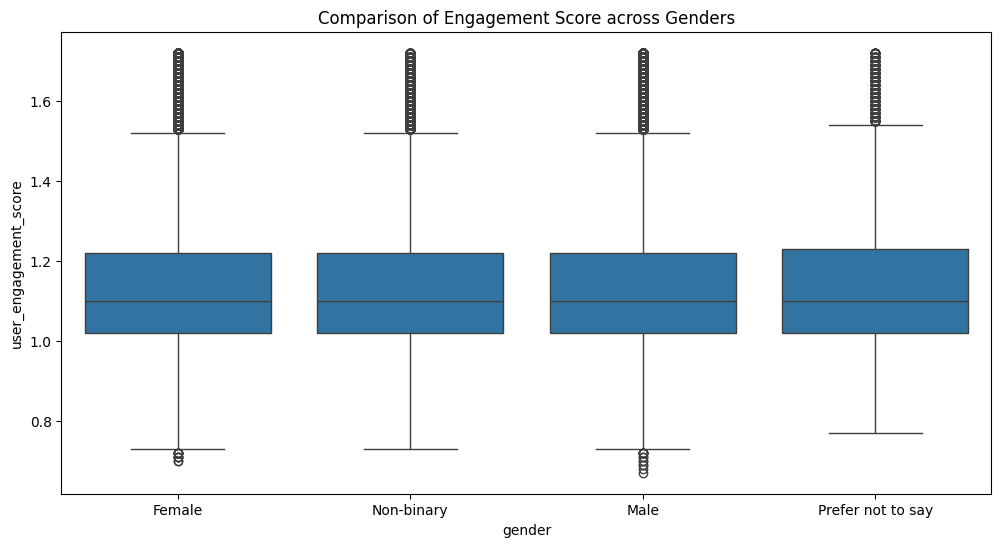

In [42]:
plt.figure(figsize=(12,6))
sns.boxplot(x='gender', y='user_engagement_score', data=df)
plt.title('Comparison of Engagement Score across Genders')
plt.show()

---------------------------
- #### **age group vs engagement seg**
-----------------------------

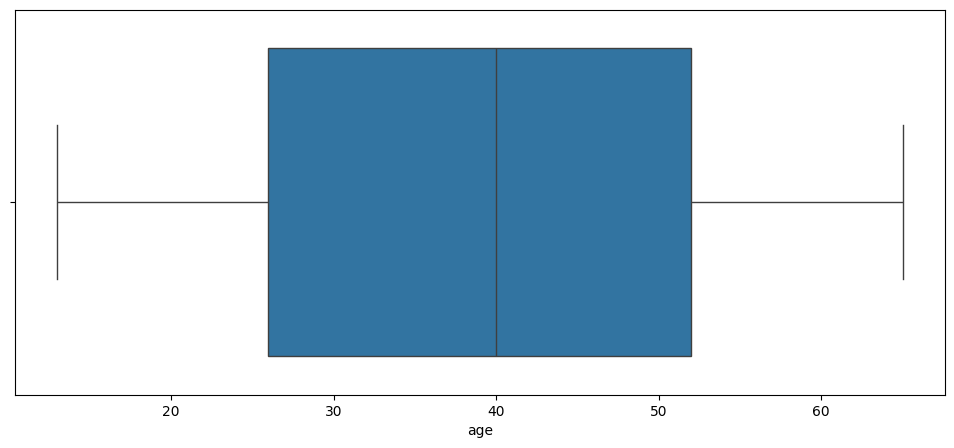

In [43]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['age'],data=df)
plt.show()

In [44]:
bins = [13, 20, 30, 45, 60, 100]
labels = ['Teen', 'Young', 'Adult', 'Middle', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

In [45]:
crosst = pd.crosstab(df['age_group'], df['engagement_seg'])
crosst

engagement_seg,Casual Users,Passive Users,Power Users
age_group,,,
Teen,106104,114,25882
Young,164064,705,33003
Adult,262881,1935,43446
Middle,258625,1751,49425
Senior,100849,701,20799


In [46]:
chi2_contingency(crosst, correction = False)

Chi2ContingencyResult(statistic=np.float64(2864.3340154699076), pvalue=np.float64(0.0), dof=8, expected_freq=array([[110159.8158059 ,    642.55150969,  21297.63268441],
       [164924.50485665,    961.98862358,  31885.50651976],
       [257063.47569991,   1499.42629433,  49699.09800576],
       [258346.86674098,   1506.91218966,  49947.22106936],
       [102028.33689656,    595.12138274,  19725.5417207 ]]))

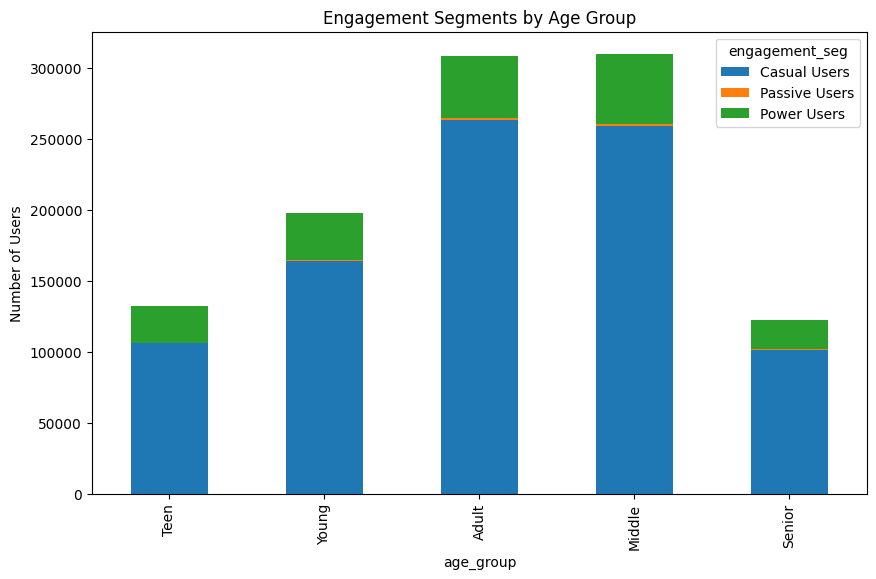

In [47]:
crosst.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Engagement Segments by Age Group')
plt.ylabel('Number of Users')
plt.show()

#### **Teens Category**
- ##### Dominant Behavior: Power Users
- ##### Analysis: The data showed that teenagers are the most enthusiastic group; their actual number significantly exceeded statistical expectations in the Power Users category (approximately 25,800 compared to the expected 21,300).
- ##### Conclusion: This group is not inclined towards casual or passive use; they are either highly engaged or absent, making them the driving force behind high engagement on the platform.

#### **Young Users**
- ##### Dominant Behavior: Casual Users

- ##### Analysis: This group showed a good balance between reality and expectations, with a slight tendency towards frequent and moderate use.

- ##### Conclusion: Young people represent the platform's "stable consumption base," spending enough time browsing without necessarily reaching peak engagement levels consistently.

#### **Adults**
- ##### Dominant Behavior: Casual & Passive Users

- ##### Analysis: We observe a shift here; the number of passive users has begun to rise above expectations (1935 actual vs. 1499 expected).

- ##### Conclusion: As users age, they tend to consume content silently or less frequently, placing them in the "quiet" user category.

#### **Middle**
- ##### Dominant Behavior: A noticeable decrease in interaction intensity.

- ##### Analysis: Despite a large number of users in this group, they score lower than expected in the Power Users category.

- ##### Conclusion: This group uses the platform as a secondary tool, as they have less motivation for "quick interaction" or "engagement intensity" compared to younger groups.

#### **Senior**
- ##### Dominant Behavior: Selective Users

- ##### Analysis: The data shows that seniors follow a very predictable distribution pattern, with a high concentration in the casual user category.

- ##### Conclusion: Their interests are specific and clear, and they do not get carried away by trends of intense interaction, which makes their behavior more stable and predictable.

-------------------------------------------------------
#### **Although the direct linear correlation between crude age and score was weak (-0.06), data binning revealed a substantial and statistically significant relationship (P-value = 0.0). This demonstrates that the effect of age is more clearly seen when studying generations as behavioral groups rather than treating age as an abstract numerical value.**

------------------------------------
- #### **weekly work hours vs user engagement score**
-------------------------------------

In [48]:
r, p_value = pearsonr(df['weekly_work_hours'], df['user_engagement_score'])

print("Correlation:", r)
print("P-value:", p_value)

Correlation: -0.054578639234850734
P-value: 0.0


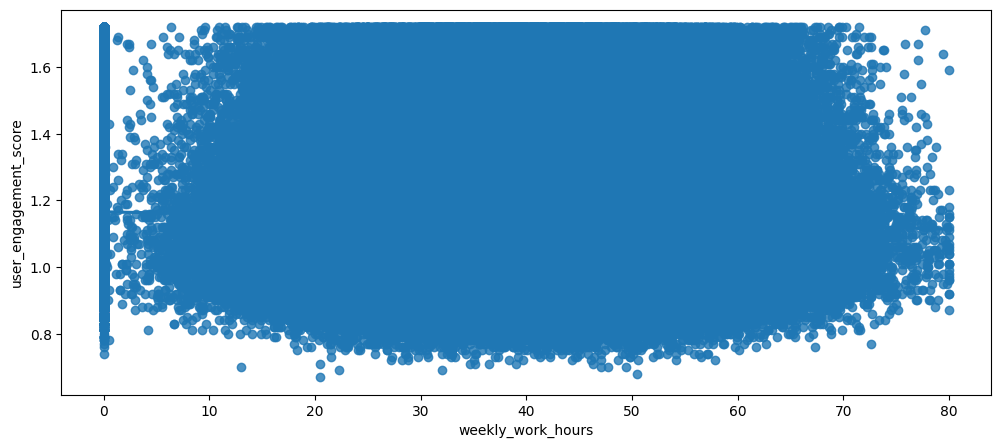

In [49]:
plt.figure(figsize=(12,5))
sns.regplot(x='weekly_work_hours',y= 'user_engagement_score',data=df)
plt.show()

In [50]:
bins = [0, 20, 35, 45, 60, 80]
labels = ['Part-time', 'Light', 'Full-time', 'Overtime', 'Extreme']

df['work_hours_group'] = pd.cut(
    df['weekly_work_hours'],
    bins=bins,
    labels=labels,
    right=False
)

In [51]:
ct = pd.crosstab(df['work_hours_group'], df['engagement_seg'])
ct

engagement_seg,Casual Users,Passive Users,Power Users
work_hours_group,,,
Part-time,94292,179,21831
Light,232621,1474,43678
Full-time,312419,2011,58962
Overtime,234303,1433,44559
Extreme,18864,109,3524


In [52]:
chi2_contingency(ct, correction=False)

Chi2ContingencyResult(statistic=np.float64(954.8686730153053), pvalue=np.float64(8.207741221891534e-201), dof=8, expected_freq=array([[9.69853266e+04, 5.65721206e+02, 1.87509522e+04],
       [2.31637505e+05, 1.35115541e+03, 4.47843393e+04],
       [3.11375085e+05, 1.81626947e+03, 6.02006460e+04],
       [2.33740625e+05, 1.36342303e+03, 4.51909523e+04],
       [1.87604589e+04, 1.09430878e+02, 3.62711020e+03]]))

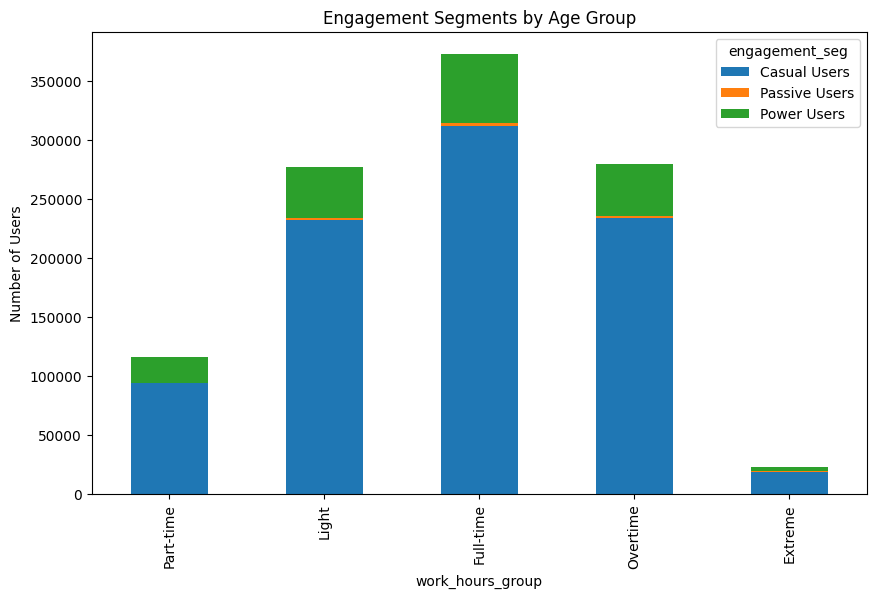

In [53]:
ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Engagement Segments by Age Group')
plt.ylabel('Number of Users')
plt.show()

#### **Part-time Users**
- ##### Reality: 21,831 registered as Power Users.
- ##### Expectation: Statistically, 18,750 were expected.
- ##### Analysis: This group exceeds expectations in terms of intensive engagement.
- ##### Conclusion: Because they are not tied to full-time work, they possess "digital energy" and free time, allowing them to focus their engagement and become Power Users.

#### **Full-time Users**
- ##### Reality: 312,419 registered as Casual Users.

- ##### Expectation: 311,375 were expected.

- ##### Analysis: The numbers are very close, indicating that this group represents the platform's "standard."

- ##### Conclusion: Full-time users represent the largest segment of regular, daily users of the application, without overuse or underuse.

#### **Overtime & Extreme Work Category**
- ##### Reality: We observe a decrease in the number of Power Users compared to expectations in the Extreme category.

- ##### Analysis: The greater the workload (working hours), the less likely the user is to be a "Power User."

- ##### Conclusion: Time constraints and work-related stress push users into the Casual or Passive category, where they only skim content.

---------------------------------------------------
- #### reels watched per day vs user engagement score
---------------------------------------------------

In [54]:
r, p_value = pearsonr(df['reels_watched_per_day'], df['user_engagement_score'])
print("Correlation:", r)
print("P-value:", p_value)

Correlation: -0.4318168848002997
P-value: 0.0


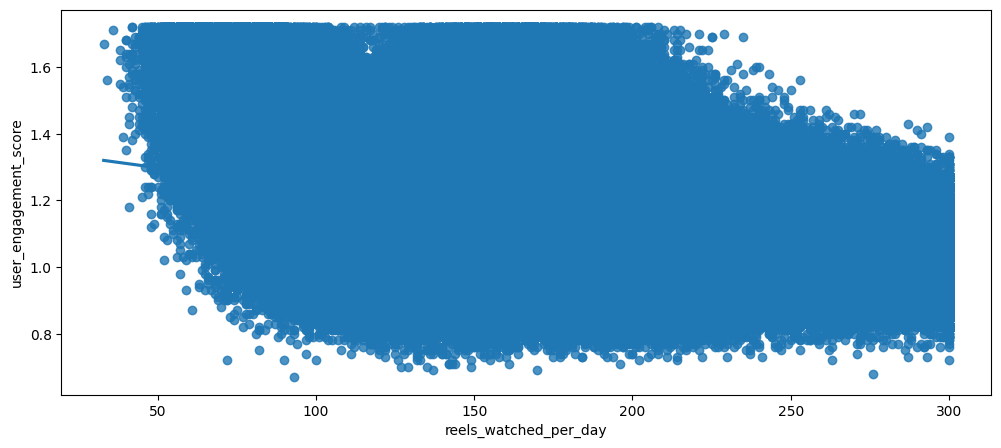

In [55]:
plt.figure(figsize=(12,5))
sns.regplot(x='reels_watched_per_day',y= 'user_engagement_score',data=df)
plt.show()

In [56]:
bins = [0, 20, 60, 150, df['reels_watched_per_day'].max()]
labels = ['Light Viewer', 'Moderate Viewer', 'Heavy Viewer', 'Binge Watcher']

df['reels_watch_segment'] = pd.cut(df['reels_watched_per_day'], bins=bins, labels=labels, include_lowest=True)

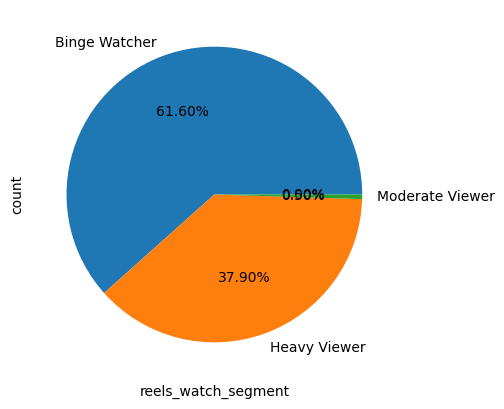

In [57]:
pie(df,'reels_watch_segment')

In [58]:
cts = pd.crosstab(df['age_group'], df['reels_watch_segment'])
cts

reels_watch_segment,Moderate Viewer,Heavy Viewer,Binge Watcher
age_group,,,
Teen,0,1708,130392
Young,0,4445,193327
Adult,1931,160559,145772
Middle,2376,169841,137584
Senior,1034,69082,52233


In [59]:
chi2_contingency(cts,correction=False)

Chi2ContingencyResult(statistic=np.float64(270122.963990276), pvalue=np.float64(0.0), dof=8, expected_freq=array([[   659.21390958,  50065.57465121,  81375.21143921],
       [   986.93454448,  74955.1009078 , 121829.96454773],
       [  1538.30884326, 116830.53878223, 189893.15237451],
       [  1545.98885997, 117413.81599183, 190841.1951482 ],
       [   610.55384272,  46369.96966693,  75368.47649035]]))

##### The χ² test revealed a strong correlation between age and Reels viewing patterns (P-value = 0.0). Younger age groups showed a clear bias towards the Binge Watcher category, with actual figures exceeding statistical expectations by a significant margin, confirming that short-form content is the primary driver of well-time for younger generations.

--------------------------------
- #### reels watch segment vs engagement score
- --------------------------------

In [60]:
cts2 = pd.crosstab(df['engagement_seg'], df['reels_watch_segment'])
cts2

reels_watch_segment,Moderate Viewer,Heavy Viewer,Binge Watcher
engagement_seg,,,
Casual Users,357,290915,601251
Passive Users,0,1345,3861
Power Users,4984,113375,54196


In [61]:
chi2_contingency(cts2,correction=False)

Chi2ContingencyResult(statistic=np.float64(96042.9872622109), pvalue=np.float64(0.0), dof=4, expected_freq=array([[4.45392563e+03, 3.38264019e+05, 5.49805056e+05],
       [2.59793158e+01, 1.97306118e+03, 3.20695951e+03],
       [8.61095050e+02, 6.53979200e+04, 1.06295985e+05]]))

#### The Chi-Square Crosstab test revealed some surprising facts:

- ##### Casual Users: These are the biggest "victims" of the Reels algorithm, as they are drawn to binge-watching in numbers far exceeding statistical predictions.

- ##### Passive Users: These include "silent consumers" who spend hours watching without leaving an interactive trace, suggesting they are either new users or prefer passive consumption.

- ##### Power Users: These possess "consumer intelligence"; they focus their activity on heavy viewing but avoid binge-watching to maintain their interactive engagement.

---------------------------------

In [62]:
r, p_value = pearsonr(df['perceived_stress_score'], df['user_engagement_score'])

print("Correlation:", r)
print("P-value:", p_value)

Correlation: -0.507774276900976
P-value: 0.0


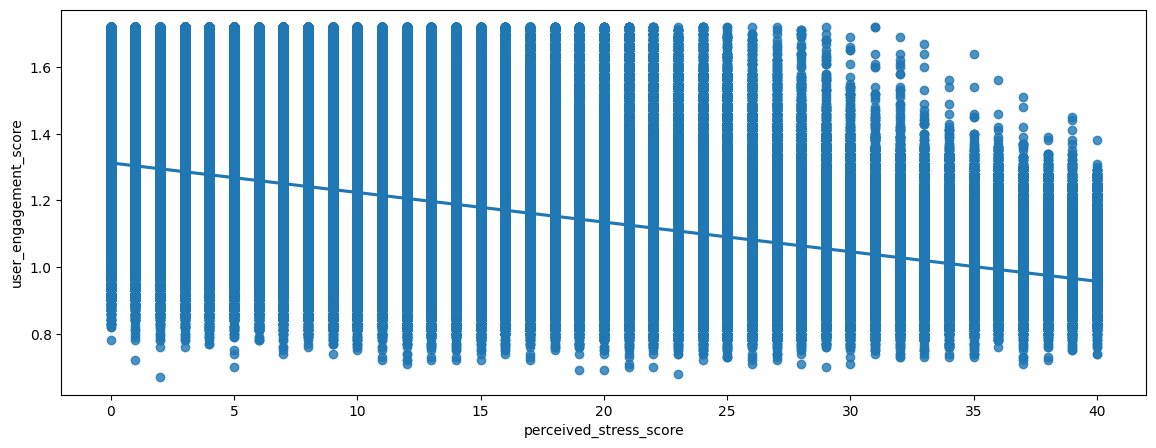

In [63]:
plt.figure(figsize=(14,5))
sns.regplot(x=df['perceived_stress_score'], y=df['user_engagement_score'],data=df)
plt.show()

In [64]:
df['stress_category'] = pd.cut(df['perceived_stress_score'], 
                               bins=3, 
                               labels=['Low', 'Medium', 'High'])

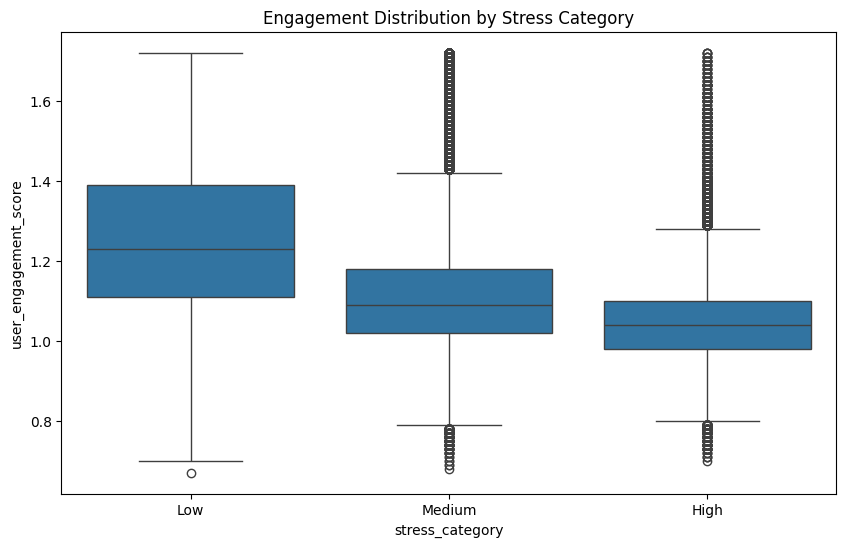

In [65]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='stress_category', y='user_engagement_score', data=df)
plt.title('Engagement Distribution by Stress Category')
plt.show()

##### **We clearly observe that the median—the horizontal line inside the box—gradually decreases as we move from low to high voltage. This confirms that voltage is not simply a "present factor," but a powerful influence that systematically reduces reaction rates.**
##### **These are the "exceptions" who deserve to be studied. What enables them to maintain high engagement despite the pressures? Is it the nature of the content? Or do they possess specific coping mechanisms?**

In [66]:
low = df[df['stress_category'] == 'Low']['user_engagement_score']
medium = df[df['stress_category'] == 'Medium']['user_engagement_score']
high = df[df['stress_category'] == 'High']['user_engagement_score']

In [67]:
Shapiro(low)

Shapiro-Wilk Statistic: 0.9729, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 339087.
  res = hypotest_fun_out(*samples, **kwds)


In [68]:
Shapiro(medium)

Shapiro-Wilk Statistic: 0.9341, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 452273.
  res = hypotest_fun_out(*samples, **kwds)


In [69]:
Shapiro(high)

Shapiro-Wilk Statistic: 0.9838, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 278924.
  res = hypotest_fun_out(*samples, **kwds)


In [70]:
stat, p_value_k = kruskal(low, medium, high)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 236470.78316596168
P-value: 0.0
There is a significant difference


In [71]:
! pip install scikit_posthocs

In [72]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(df, val_col='user_engagement_score', 
                          group_col='stress_category', 
                          p_adjust='bonferroni')
print(posthoc)

        Low  Medium  High
Low     1.0     0.0   0.0
Medium  0.0     1.0   0.0
High    0.0     0.0   1.0


##### **The differences between all categories without exception are statistically very strong.**
##### **A gradual and continuous effect: Tension does not only have an effect when it reaches the "high" stage, but the transition from "low" to "medium" leads to a real and tangible change in the interaction, as does the transition from "medium" to "high"**

--------------------------------
- ##### **time on feed per day vs user engagement score**
-------------------------------

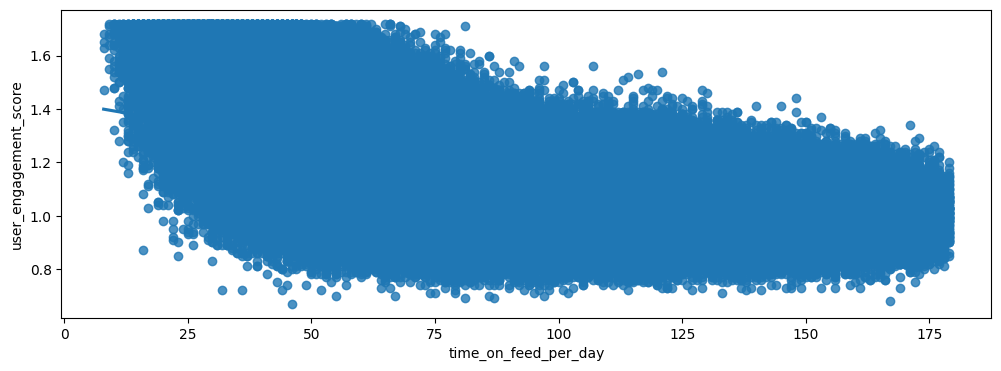

In [73]:
plt.figure(figsize=(12,4))
sns.regplot(x=df['time_on_feed_per_day'],y=df['user_engagement_score'], data=df)
plt.show()

In [74]:
r, p_value = pearsonr(df['time_on_feed_per_day'], df['user_engagement_score'])

print("Correlation:", r)
print("P-value:", p_value)

Correlation: -0.6570209124776295
P-value: 0.0


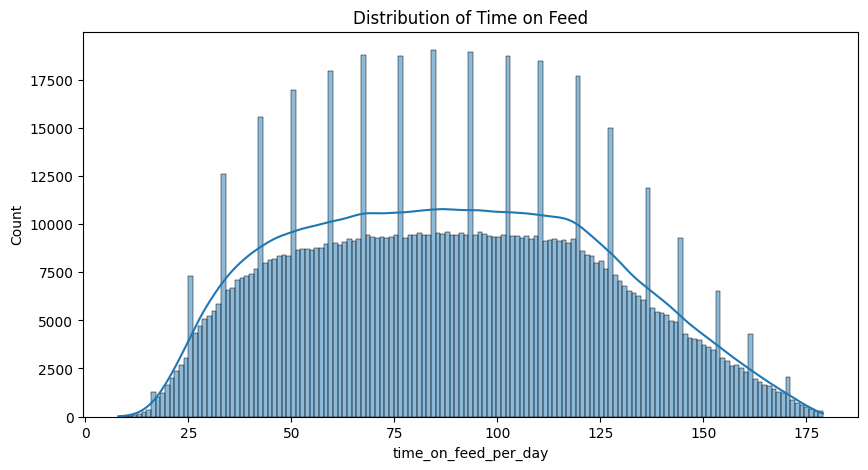

In [75]:
plt.figure(figsize=(10, 5))
sns.histplot(df['time_on_feed_per_day'], kde=True)
plt.title('Distribution of Time on Feed')
plt.show()

In [76]:
bins = [0, 50, 100, 150, df['time_on_feed_per_day'].max()]
labels = ['Casual', 'Regular', 'Active', 'Power User']

df['usage_level'] = pd.cut(df['time_on_feed_per_day'], bins=bins, labels=labels)

In [77]:
df['usage_level'].value_counts()

usage_level
Regular       462438
Active        367690
Casual        189736
Power User     50420
Name: count, dtype: int64

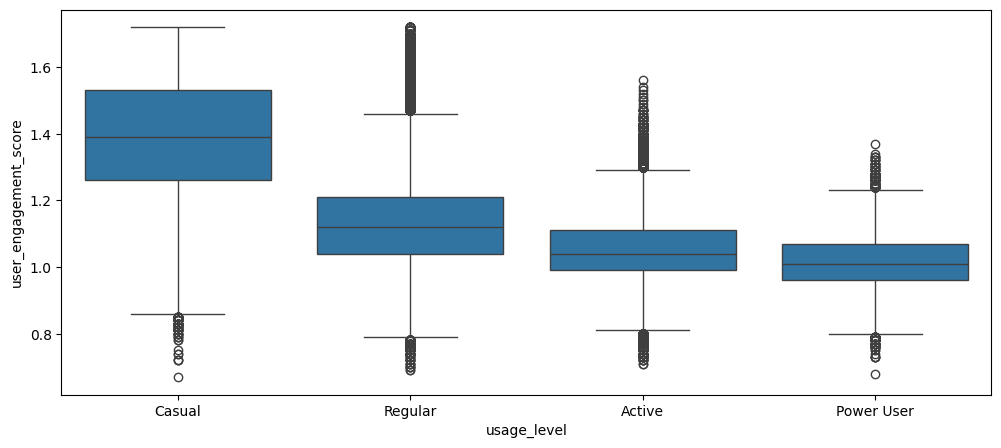

In [79]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['usage_level'], y=df['user_engagement_score'], data=df)
plt.show()

#### **1) Quality vs. Quantity of Time**
- ##### Casual User Category: Their app usage seems to be purposeful; they open the app, view the most important posts, interact with them, and then close the app. Therefore, their interaction rate per minute is very high.

- ##### Power User Category: These users often engage in passive scrolling. They scroll through the screen simply to pass the time without any real focus, which explains their low median and low variance; their behavior becomes automated and monotonous.

#### **2) The "Boredom and Distraction" Hypothesis**

- ##### Distraction: The longer the user spends on a post, the less attention they pay to its quality, leading them to ignore interaction buttons.

- ##### Content Depletion: The algorithm may initially show the user "best" content (stimulating engagement), but as the user remains engaged for an extended period, it begins to display "lower quality" or "off-interest" content, reducing the desire to interact.

- ##### Multitasking: As mentioned, a user spending three hours on a post might be engaged in Direct Messages or simply leaving the app open without actively participating, thus lowering the average engagement rate.

In [92]:
df['Engagement Density'] = df['user_engagement_score']/df['time_on_feed_per_day']

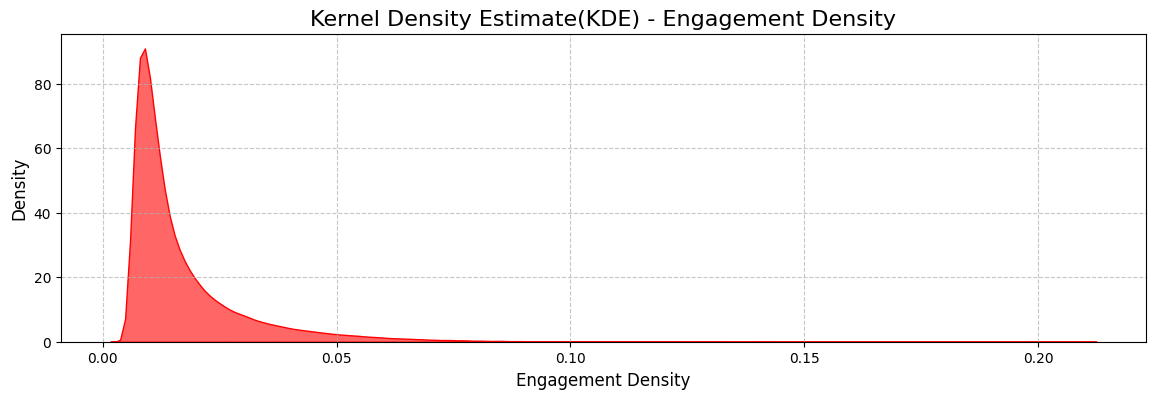

In [96]:
plt.figure(figsize=(14,	4))
sns.kdeplot(df['Engagement Density'], fill=True,	color='red', alpha=0.6)
plt.title('Kernel Density Estimate(KDE) - Engagement Density',	fontsize=16)
plt.xlabel('Engagement Density', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### **1) Skewness Analysis**
- ##### Peak: We observe a very sharp peak at low values (close to 0.01). This indicates that the vast majority of users have minimal engagement relative to their time spent on the platform.

- ##### Long Tail: The curve extends to the right, reaching values close to 0.20. This region represents the "golden users" who engage very intensely over a short period. These are likely the Casual users we identified in the previous Box Plot.

#### **2) Confirming the "Boredom and Distraction" Hypothesis**
#### Based on the distribution shown in the graph:

- ##### If the time spent increased engagement linearly, we would see the distribution centered around a higher average value.

- ##### However, the concentration at the lower values proves that increasing time on the feed does not necessarily lead to increased engagement; rather, engagement becomes more dispersed and less focused as the session lasts longer.

--------------------------------
- ##### **time on feed per day vs age seg**
-------------------------------

In [83]:
cts3 = pd.crosstab(df['age_group'], df['usage_level'])
cts3

usage_level,Casual,Regular,Active,Power User
age_group,,,,
Teen,15273,58130,51117,7580
Young,29007,85867,72514,10384
Adult,55601,131805,106110,14746
Middle,63395,133303,100006,13097
Senior,26460,53333,37943,4613


In [91]:
print(f'statistic : {chi2_contingency(cts3,correction=False)[0]}')
print(f'p_value : {chi2_contingency(cts3,correction=False)[1]}')
print(f'dof=12 : {chi2_contingency(cts3,correction=False)[2]}')
pd.DataFrame(chi2_contingency(cts3,correction=False)[3])

statistic : 8917.160895704292
p_value : 0.0
dof=12 : 12


,0,1,2,3
0,23418.200777,57076.495397,45382.206031,6223.097795
1,35060.290719,85451.420498,67943.449290,9316.839493
2,54647.550400,133190.875278,105901.662344,14521.911979
3,54920.378643,133855.831572,106430.377068,14594.412717
4,21689.579461,52863.377255,42032.305267,5763.738017


#### **1) Confirmation of Statistical Significance (Chi-Square Test)**
#### Chi-square test results in the second image:

- ##### P-value (0.0): This value is significantly less than 0.05, indicating a strong, albeit indirect, correlation between the age group and the pattern used.

- ##### Statistic (8917.16): This value strongly suggests a significant discrepancy between the expected and actual distribution of the categories.

#### **2) Peak Usage Analysis (The Peak)**
#### Based on the Frequency Table (cts3):

- ##### Adults: They constitute the largest demographic in the Regular and Active categories.

- ##### Young: They exhibit very high activity relative to their overall population, with their numbers in the Active category (72k) approaching those in the Regular category (85k).

- ##### Interpretation: These categories (Young & Adult) are the primary drivers of the application, and they often have a greater appetite for consuming content or using it for professional and social purposes.

#### **2) The "Gap" Between Expected and Actual Users (The Final Matrix)**

- ##### In the Senior category: We observe that the actual numbers in Power User (4613) are lower than the expected (5763).

- ##### In the Young category: The actual numbers in Power User (10384) are higher than the expected (9316).

#### **In summary: Young people tend to exceed expectations in "heavy use," while older people tend to be content with normal or casual use.**

----------------------------------------------------------


# <center><strong>Conclusion and Strategic Insights</strong></center>
--------------------------------------------
#### **This comprehensive analysis of social media user behavior has successfully decoded the intricate patterns governing digital engagement. By processing a dataset of over 1.5 million records, the project highlighted a significant disparity between statistical expectations and actual user behavior. Specifically, the 'Young' demographic consistently outperformed expectations in the 'Power User' category, whereas 'Seniors' exhibited a more conservative and casual usage pattern.**
#### **These findings underscore the importance of age-centric platform optimization. By leveraging these behavioral insights, stakeholders can refine content delivery algorithms and enhance user experience design to better align with the distinct habits of each segment, ultimately driving higher engagement and long-term platform loyalty."**

---------------------------------------

In [52]:
# !jupyter nbconvert --to html "social-media-user-classification.ipynb"